In [1]:
import pandas as pd
import xarray as xr 
import matplotlib.pyplot as plt
import numpy as np
import os
import logging
from datetime import datetime
from pathlib import Path

In [2]:
csv_dir = Path("/cluster/projects/108541-SO-SIMBA/data_tmp/output_data/DA/product/envisat/MIZ_filter_2/volume/")
csv_files = sorted(csv_dir.rglob("*.csv"))
print(f"Found {len(csv_files)} CSV files under {csv_dir}")
if len(csv_files) == 0:
    raise FileNotFoundError(f"No CSV files found under {csv_dir}. Check the output path or generate the CSVs first.")

# Read each file and concatenate into one DataFrame
dfs = [pd.read_csv(f) for f in csv_files]
all_data_env = pd.concat(dfs, ignore_index=True)

# Display the first rows to verify
all_data_env.head()


Found 10 CSV files under /cluster/projects/108541-SO-SIMBA/data_tmp/output_data/DA/product/envisat/MIZ_filter_2/volume


,time,snow_volume,snow_mass,sea_ice_volume,sea_ice_mass,sea_ice_extent,sea_ice_area,sea_ice_extent_total,sea_ice_area_total,sea_ice_volume_total,...,snow_volume_18,snow_mass_18,sea_ice_volume_18,sea_ice_mass_18,sea_ice_extent_18,sea_ice_area_18,sea_ice_extent_total_18,sea_ice_area_total_18,sea_ice_volume_total_18,sea_ice_mass_total_18
0,2002-07-01 12:00:00,1.420189e+12,4.728760e+14,2.797071e+13,2.565006e+16,0.0,1.231075e+13,0.0,1.231075e+13,2.797071e+13,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2002-07-02 12:00:00,1.423864e+12,4.737869e+14,2.599911e+13,2.384776e+16,0.0,1.235486e+13,0.0,1.235486e+13,2.599911e+13,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2002-07-03 12:00:00,1.431935e+12,4.761577e+14,2.745253e+13,2.518694e+16,0.0,1.243984e+13,0.0,1.243984e+13,2.745253e+13,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2002-07-04 12:00:00,1.453175e+12,4.829013e+14,2.631065e+13,2.414508e+16,0.0,1.264661e+13,0.0,1.264661e+13,2.631065e+13,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2002-07-05 12:00:00,1.467938e+12,4.874843e+14,2.653485e+13,2.435666e+16,0.0,1.280688e+13,0.0,1.280688e+13,2.653485e+13,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Load and concatenate all CSV files in a directory
csv_dir = Path('/cluster/projects/108541-SO-SIMBA/data_tmp/output_data/DA/product/sentinel3a_sentinel3b_cryosat2/MIZ_filter_2/volume/v5/')

# Search recursively for CSV files
csv_files = sorted(csv_dir.rglob("*.csv"))
print(f"Found {len(csv_files)} CSV files under {csv_dir}")
if len(csv_files) == 0:
    raise FileNotFoundError(f"No CSV files found under {csv_dir}. Check the output path or generate the CSVs first.")

# Read each file and concatenate into one DataFrame
dfs = [pd.read_csv(f) for f in csv_files]
all_data_mms = pd.concat(dfs, ignore_index=True)

# Display the first rows to verify
all_data_mms.head()

NameError: name 'Path' is not defined

In [ ]:
'/cluster/projects/108541-SO-SIMBA/data_tmp/output_data/DA/product/sentinel3a_sentinel3b_cryosat2/MIZ_filter_2/volume/v5/sit_25km_2019_2024_laku'

findfont: Font family 'pt-sans' not found.
findfont: Font family 'pt-sans' not found.
findfont: Font family 'pt-sans' not found.
findfont: Font family 'pt-sans' not found.
findfont: Font family 'pt-sans' not found.
findfont: Font family 'pt-sans' not found.
findfont: Font family 'pt-sans' not found.
findfont: Font family 'pt-sans' not found.
findfont: Font family 'pt-sans' not found.
findfont: Font family 'pt-sans' not found.
findfont: Font family 'pt-sans' not found.
findfont: Font family 'pt-sans' not found.
findfont: Font family 'pt-sans' not found.
findfont: Font family 'pt-sans' not found.
findfont: Font family 'pt-sans' not found.
findfont: Font family 'pt-sans' not found.
findfont: Font family 'pt-sans' not found.
findfont: Font family 'pt-sans' not found.
findfont: Font family 'pt-sans' not found.
findfont: Font family 'pt-sans' not found.
findfont: Font family 'pt-sans' not found.
findfont: Font family 'pt-sans' not found.
findfont: Font family 'pt-sans' not found.
findfont: F

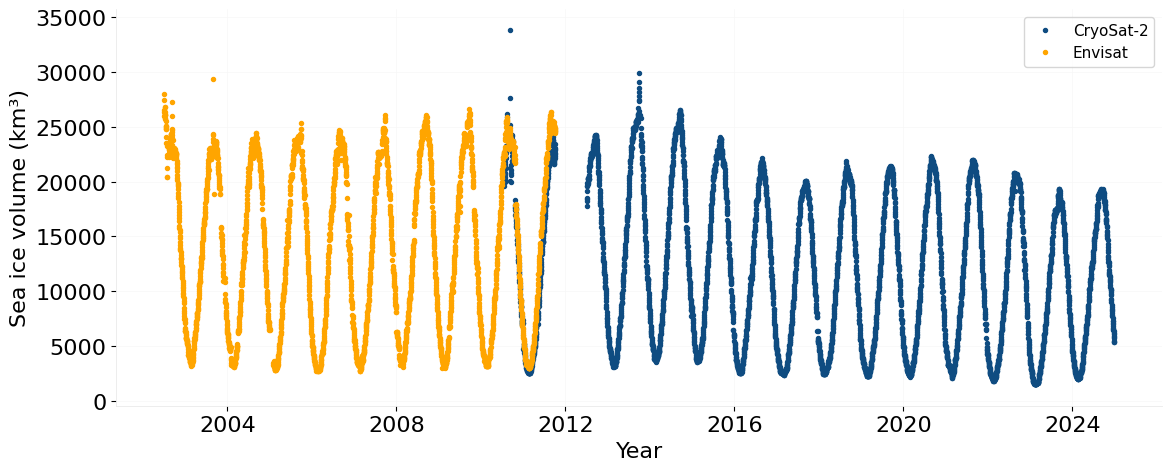

In [18]:
# Minimal, clean time series with yearly ticks and subtle vertical/horizontal grid
panel = all_data_cs2.copy()
if 'time' in panel.columns:
    panel['time'] = pd.to_datetime(panel['time'], errors='coerce')
else:
    panel['time'] = pd.to_datetime(panel.index, errors='coerce')

panel = panel.sort_values('time')

panel2 = all_data_env.copy()
if 'time' in panel2.columns:
    panel2['time'] = pd.to_datetime(panel2['time'], errors='coerce')
else:
    panel2['time'] = pd.to_datetime(panel2.index, errors='coerce')

panel2 = panel2.sort_values('time')

if 'sea_ice_volume_total' in panel.columns:
    y = 'sea_ice_volume_total'
    scale = 1e9
    ylabel = 'Sea ice volume (km³)'
elif 'sea_ice_area_total' in panel.columns:
    y = 'sea_ice_area_total'
    scale = 1e6
    ylabel = 'Sea ice area (10⁶ m²)'
elif 'sea_ice_extent_total' in panel.columns:
    y = 'sea_ice_extent_total'
    scale = 1e6
    ylabel = 'Sea ice extent (10⁶ m²)'
else:
    y = panel.columns[0]
    scale = 1
    ylabel = y.replace('_', ' ').title()

import matplotlib.dates as mdates
from matplotlib.dates import DateFormatter

# Build series and ensure missing values are NaN so matplotlib breaks the line
series = panel[y].astype(float) / scale
series.replace([np.inf, -np.inf], np.nan, inplace=True)
# If date is missing, treat value as missing too so the line is broken
series.loc[panel['time'].isna()] = np.nan

# Year ticks: choose interval so we have ~4-6 ticks
years = panel['time'].dt.year.dropna()
if len(years) == 0:
    raise ValueError('No valid dates found in `time` for plotting.')
yr_min = int(years.min())
yr_max = int(years.max())
year_span = max(1, yr_max - yr_min)
interval = max(1, year_span // 5)


series2 = panel2[y].astype(float) / scale
series2.replace([np.inf, -np.inf], np.nan, inplace=True)
# If date is missing, treat value as missing too so the line is broken
series2.loc[panel2['time'].isna()] = np.nan

# Year ticks: choose interval so we have ~4-6 ticks
years2 = panel2['time'].dt.year.dropna()
if len(years2) == 0:
    raise ValueError('No valid dates found in `time` for plotting.')
yr_min2 = int(years2.min())
yr_max2 = int(years2.max())
year_span2 = max(1, yr_max2 - yr_min2)
interval2 = max(1, year_span2 // 5)


plt.rcParams.update({
    'font.family': 'pt-sans',
    'font.size': 16,
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'axes.linewidth': 0.6,
})

fig, ax = plt.subplots(figsize=(12, 5))
# Plot contiguous non-NaN segments separately so lines do NOT connect across NaNs
vals = series.values
mask = ~np.isnan(vals)
if mask.any():
    idx = np.where(mask)[0]
    splits = np.split(idx, np.where(np.diff(idx) > 1)[0] + 1)
    for seg in splits:
        seg_times = panel['time'].iloc[seg]
        seg_vals = vals[seg]
        ax.plot(seg_times, seg_vals, color='#0f4c81', linewidth=0,
                marker='.', markersize=6, markeredgewidth=0.9,
                markeredgecolor='#0f4c81', markerfacecolor='#0f4c81', zorder=3, label='CryoSat-2')

vals2 = series2.values
mask2 = ~np.isnan(vals2)
if mask2.any():
    idx = np.where(mask2)[0]
    splits = np.split(idx, np.where(np.diff(idx) > 1)[0] + 1)
    for seg in splits:
        seg_times = panel2['time'].iloc[seg]
        seg_vals = vals2[seg]
        ax.plot(seg_times, seg_vals, color='orange', linewidth=0,
                marker='.', markersize=6, markeredgewidth=0.9,
                markeredgecolor='orange', markerfacecolor='orange', zorder=3, label='Envisat')


# Set y limits with little padding
valid = series.dropna()
if len(valid):
    yrange = valid.max() - valid.min()
    pad = yrange * 0.06 if yrange > 0 else max(0.5, valid.max() * 0.06)
    ax.set_ylim(valid.min() - pad, valid.max() + pad)

# Year locator + formatter
#ax.xaxis.set_major_locator(mdates.YearLocator(interval=interval))
ax.xaxis.set_major_formatter(DateFormatter('%Y'))
#ax.xaxis.set_minor_locator(None)

# Grid: both horizontal and vertical, very subtle and thin
ax.set_axisbelow(True)
ax.grid(which='major', axis='y', linestyle='-', color='#f7f7f7', linewidth=0.5)
ax.grid(which='major', axis='x', linestyle='-', color='#f7f7f7', linewidth=0.5)

# Minimal spines
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#eaeaea')
ax.spines['left'].set_color('#eaeaea')
ax.spines['bottom'].set_linewidth(0.6)
ax.spines['left'].set_linewidth(0.6)

# Labels and ticks
ax.set_title('', pad=6)
ax.set_xlabel('Year', fontsize=16)
ax.set_ylabel(ylabel, fontsize=16)
ax.tick_params(axis='x', rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

KeyError: 'date'

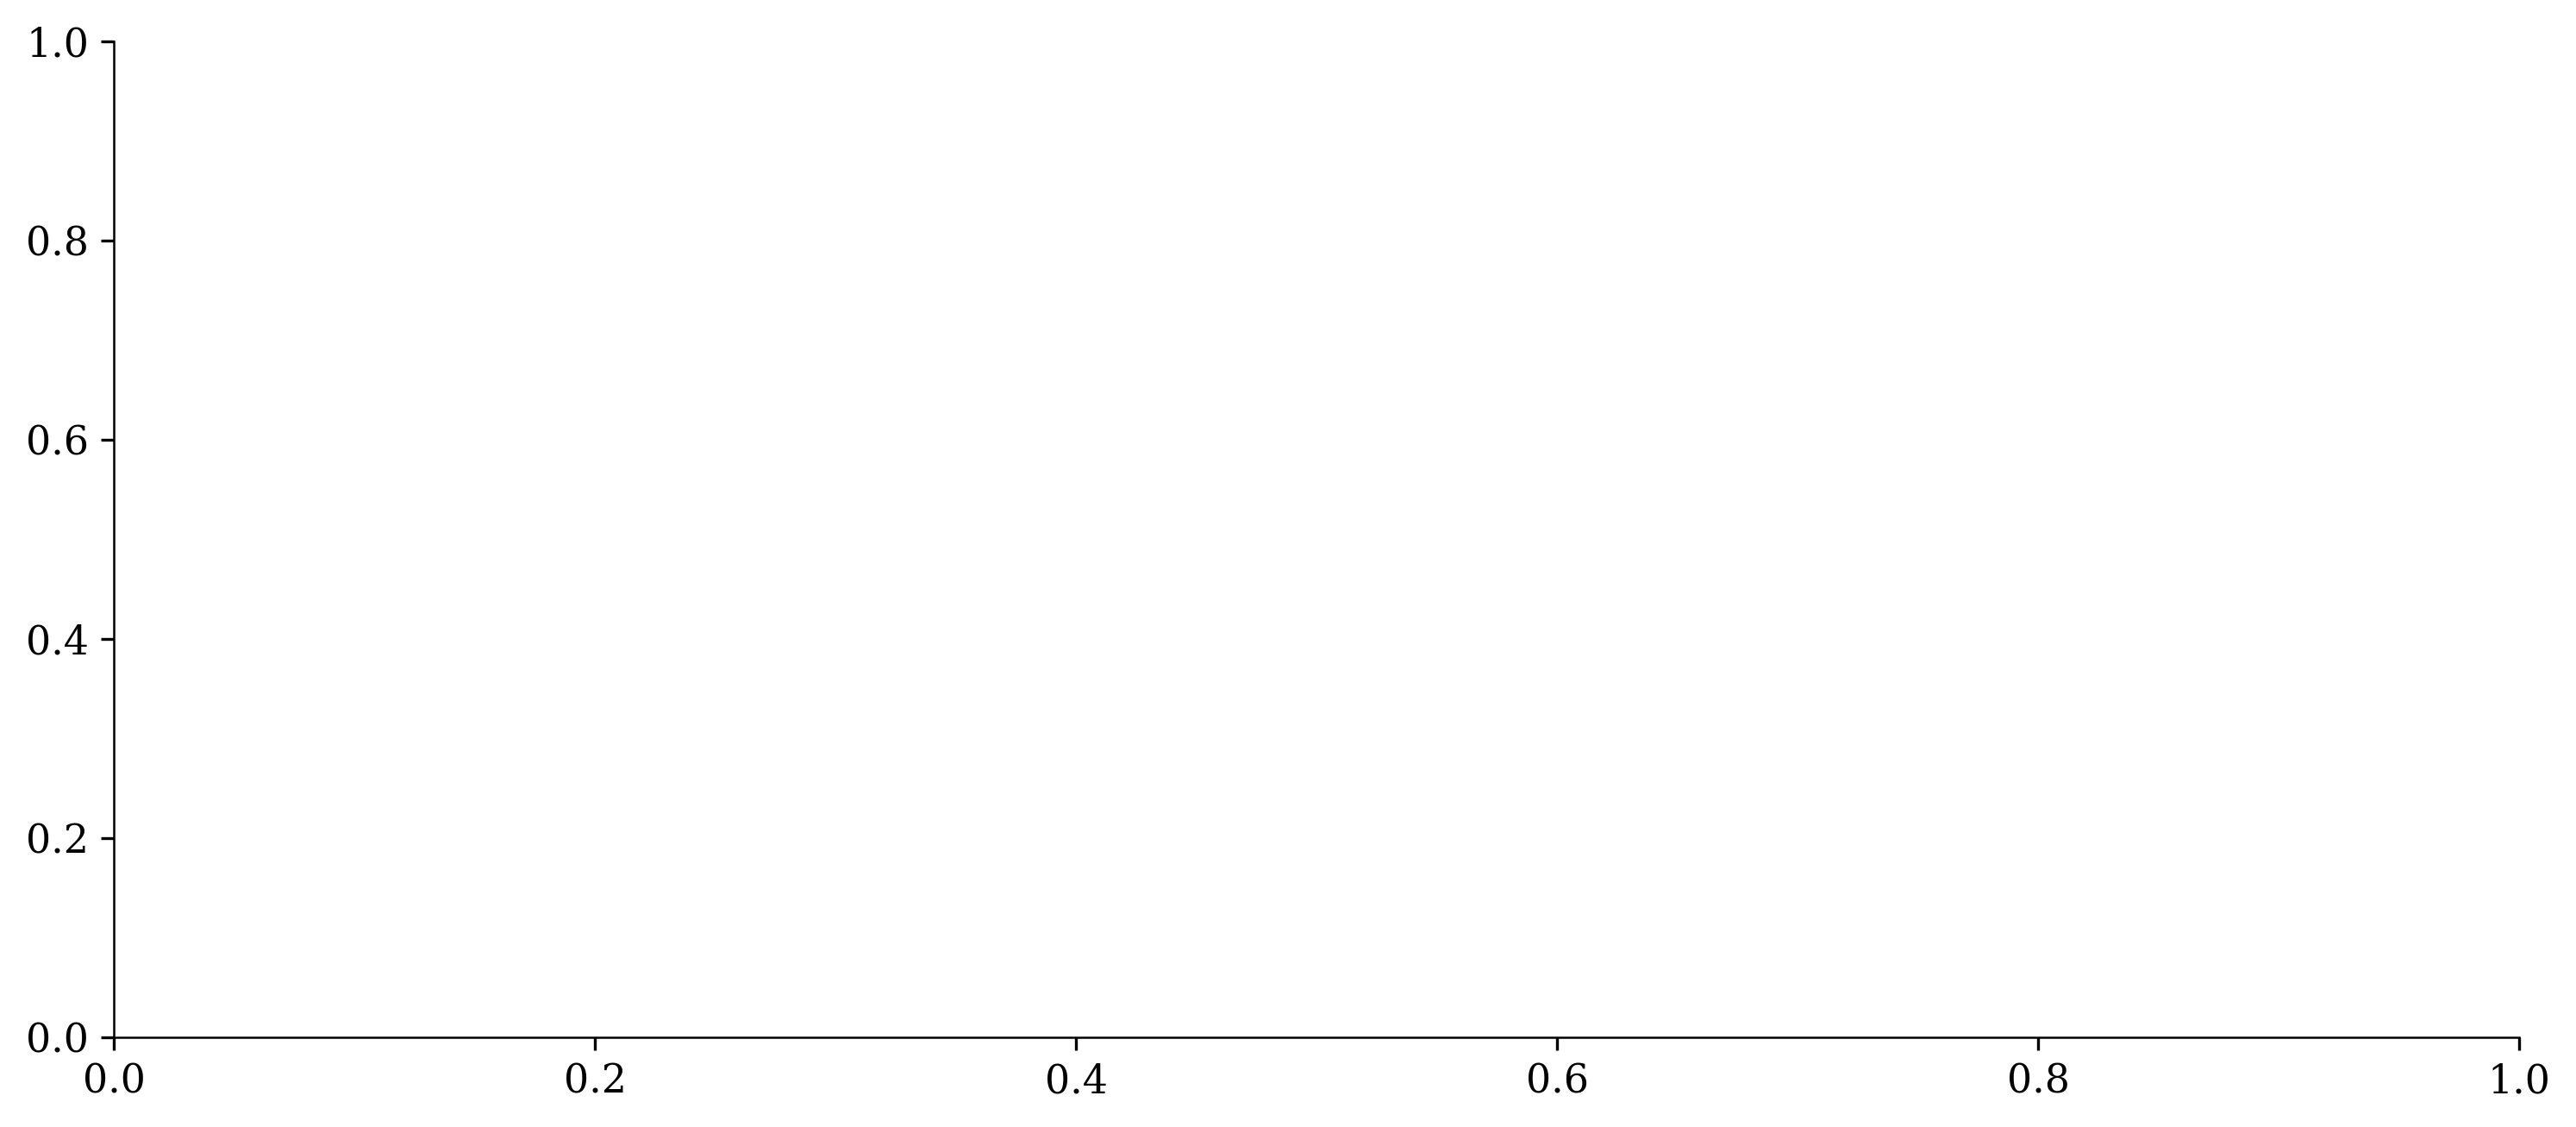

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- Style global publication ---
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "font.size": 12,

    "axes.labelsize": 13,
    "axes.titlesize": 15,

    "xtick.labelsize": 11,
    "ytick.labelsize": 11,

    "legend.fontsize": 11,

    "axes.spines.top": False,
    "axes.spines.right": False,
})

# --- Sécurité dates ---
all_data_cs2["time"] = pd.to_datetime(all_data_cs2["time"])
all_data_env["time"] = pd.to_datetime(all_data_env["time"])

# --- Figure ---
fig, ax = plt.subplots(figsize=(12, 5), dpi=300)

# Couleurs plus élégantes
cs2_color = "#3B5B92"   # bleu désaturé
env_color = "#D98C3F"   # orange doux

# --- Points uniquement ---
ax.plot(
    all_data_cs2["date"],
    all_data_cs2["sea_ice_volume"],
    linestyle="None",
    marker="o",
    markersize=2.8,
    alpha=0.75,
    color=cs2_color,
    markeredgewidth=0,
    label="CryoSat-2"
)

ax.plot(
    all_data_env["date"],
    all_data_env["sea_ice_volume"],
    linestyle="None",
    marker="o",
    markersize=2.8,
    alpha=0.75,
    color=env_color,
    markeredgewidth=0,
    label="Envisat"
)

# --- Titre / labels ---
ax.set_title(
    "Arctic Sea Ice Volume",
    pad=18,
    weight="semibold"
)

ax.set_xlabel("Year")
ax.set_ylabel(r"Sea Ice Volume ($km^3$)")

# --- Grid publication ---
ax.grid(
    True,
    which="major",
    linestyle="--",
    linewidth=0.6,
    alpha=0.25
)

# --- Ticks temporels propres ---
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# --- Légende propre ---
ax.legend(
    frameon=False,
    loc="upper right"
)

# --- Marges élégantes ---
ax.margins(x=0.01)

plt.tight_layout()

plt.show()

In [10]:
import matplotlib.pyplot as plt

# Style propre type papier
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(11, 5), dpi=300)

# Couleurs plus élégantes
cs2_color = "#1f77b4"   # bleu scientifique classique
env_color = "#ff7f0e"   # orange matplotlib propre

# Scatter uniquement
ax.scatter(
    all_data_cs2["time"],
    all_data_cs2["sea_ice_volume"],
    s=22,
    color=cs2_color,
    alpha=0.85,
    label="CryoSat-2",
    edgecolors="none"
)

ax.scatter(
    all_data_env["time"],
    all_data_env["sea_ice_volume"],
    s=22,
    color=env_color,
    alpha=0.85,
    label="Envisat",
    edgecolors="none"
)

# Labels propres
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Sea Ice Volume (m^3)", fontsize=12)

# Titre
ax.set_title(
    "Arctic Sea Ice Volume Comparison",
    fontsize=14,
    pad=15
)

# Grid discrète
ax.grid(
    True,
    linestyle="--",
    linewidth=0.6,
    alpha=0.5
)

# Retirer bordures inutiles
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Légende élégante
ax.legend(
    frameon=False,
    fontsize=11
)

# Tick labels plus propres
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(11, 5), dpi=300)

ax.plot(
    all_data_cs2["time"],
    all_data_cs2["sea_ice_volume"],
    linestyle="None",
    marker="o",
    markersize=3,
    alpha=0.8,
    color="#1f77b4",
    label="CryoSat-2"
)

ax.plot(
    all_data_env["time"],
    all_data_env["sea_ice_volume"],
    linestyle="None",
    marker="o",
    markersize=3,
    alpha=0.8,
    color="#ff7f0e",
    label="Envisat"
)

ax.set_xlabel("Date")
ax.set_ylabel("Sea Ice Volume")

ax.grid(True, linestyle="--", alpha=0.5)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

<Axes: >

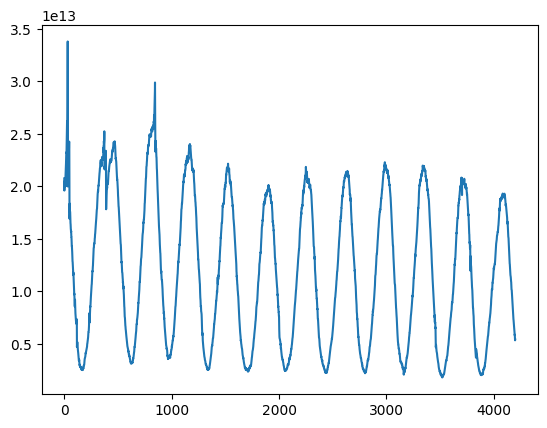

In [4]:
all_data_cs2["sea_ice_volume"].plot()